<h1> Prediction of Final Steel Temperature at a Steel Production Plant</h1> 

<h2> Part 1. Data Preprocessing</h2> 

<h3>1.1. Imports</h3> 

<h4>1.1.1. Libraries</h4> 

In [ ]:
import os
from dotenv import load_dotenv
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import sklearn
from sklearn.ensemble import IsolationForest 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

import pyod
from pyod.models.knn import KNN 

import catboost
from catboost import CatBoostRegressor

import optuna

import time
import warnings
warnings.filterwarnings('ignore')

#plt.style.use('dark_background')

print('Libraries loaded')

Библиотеки загружены


<h4>1.1.2. Environment Variables</h4> 

In [ ]:
# Load environment variables
load_dotenv()

In [ ]:
# Constants
# Data directory
DATA_DIR = os.getenv('DATA_DIR', './data')
# Results directory
RESULTS_DIR = os.getenv('RESULTS_DIR', './results')

<h3>1.2. Load Data</h3> 

In [ ]:
arc = pd.read_csv(Path(DATA_DIR, 'data_arc_new.csv'))    
bulk = pd.read_csv(Path(DATA_DIR, 'data_bulk_new.csv'))
bulk_time = pd.read_csv(Path(DATA_DIR, 'data_bulk_time_new.csv'))
gas = pd.read_csv(Path(DATA_DIR, 'data_gas_new.csv'))
wire = pd.read_csv(Path(DATA_DIR, 'data_wire_new.csv'))
wire_time = pd.read_csv(Path(DATA_DIR, 'data_wire_time_new.csv'))
temp = pd.read_csv(Path(DATA_DIR, 'data_temp_new.csv'))

print('Data files loaded')

Файлы данных загружены


<h3>1.3. Exploratory Data Analysis</h3> 

<h4>1.3.1. General Dataset Information</h4> 

In [ ]:
datasets = {
    "Dataset 'arc': electrode data": arc,
    "Dataset 'bulk': bulk materials amounts": bulk,
    "Dataset 'bulk_time': bulk materials addition time": bulk_time,
    "Dataset 'gas': gas volume": gas,
    "Dataset 'wire': wire materials amounts": wire,
    "Dataset 'wire_time': wire materials addition time": wire_time,
    "Dataset 'temp': steel temperature": temp
}

In [ ]:
for dataset_name, dataset in datasets.items():
    print(f'{dataset_name}')
    display(dataset.head(3))
    display(dataset.info())
    display(dataset.describe())
    print(f'Number of full duplicates: {dataset.duplicated().sum()}')
    print(f'Number of unique keys: {len(dataset["key"].unique())}')
    print('')
    

Dataset 'arc': electrodes


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


...

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  object 
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 424.2+ KB


None

,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


Number of full dublicates: 0
Number of unique keys: 3216



<h4>1.3.2. Data Distribution Plots</h4> 

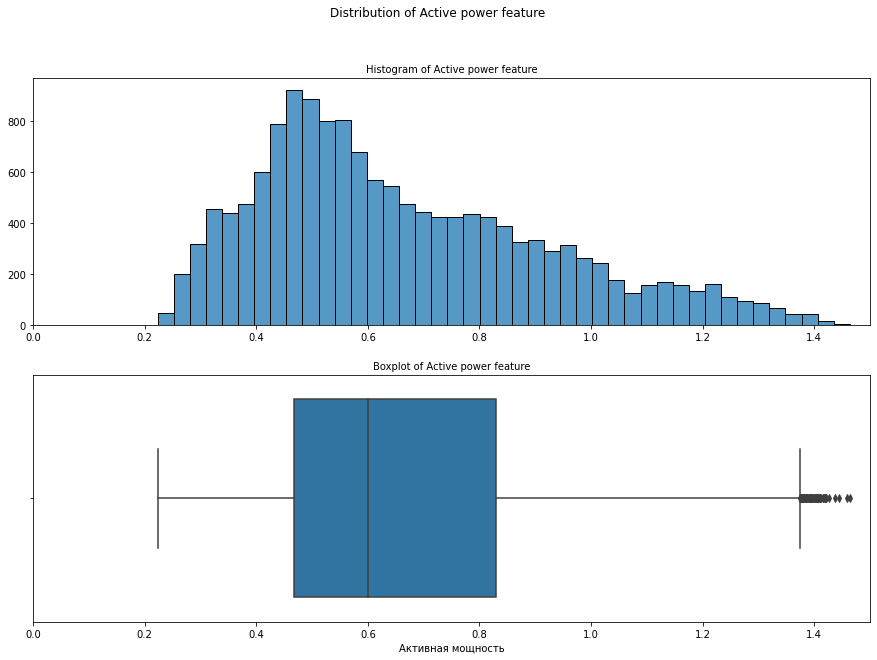

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Active Power Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(arc['Активная мощность'], kde=False)
plt.xlim(0, 1.5)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Active Power Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(arc['Активная мощность'], orient='h')
plt.xlim(0, 1.5)
plt.title('Boxplot of Active Power Feature', fontsize=10)

plt.show()

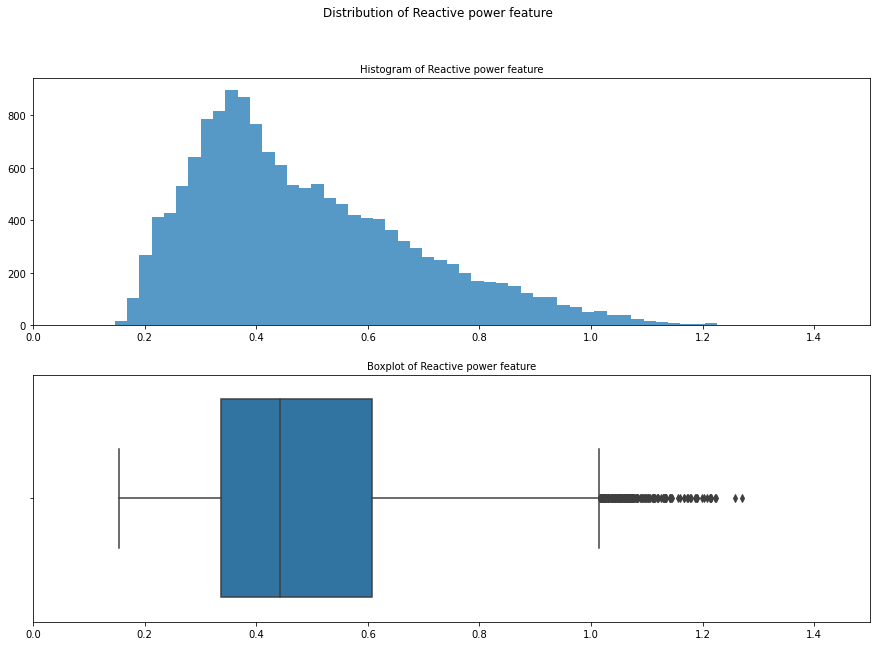

Минимальное значение Реактивной мощности после исключени выброса: 0.153777


In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Reactive Power Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(arc['Реактивная мощность'], kde=False)
plt.xlim(0, 1.5)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Reactive Power Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(arc['Реактивная мощность'], orient='h')
plt.xlim(0, 1.5)
plt.xlabel('')
plt.title('Boxplot of Reactive Power Feature', fontsize=10)

plt.show()

print(f'Minimum Reactive Power value after excluding outlier: {arc["Реактивная мощность"].nsmallest(2).iloc[-1]}')

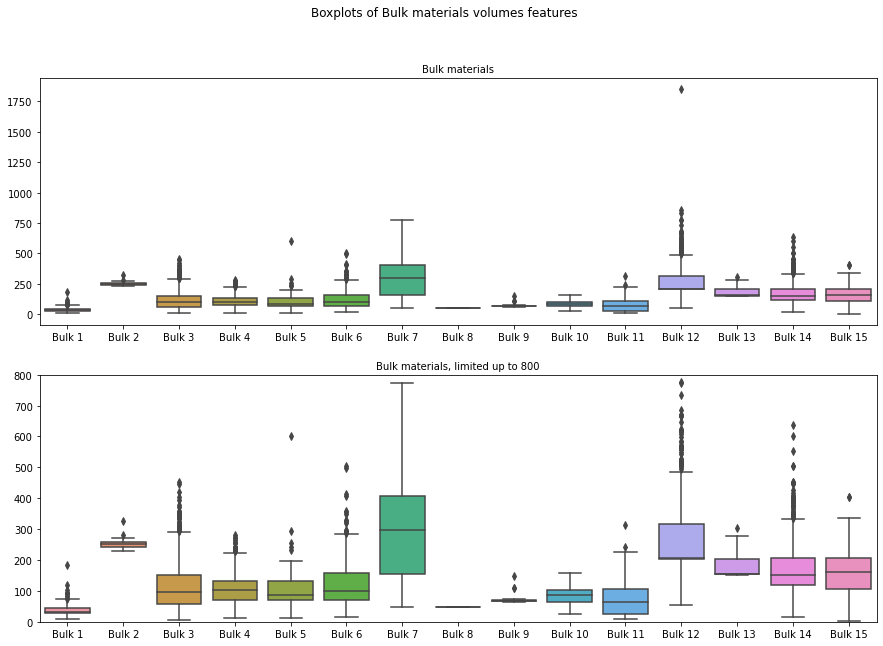

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Bulk Materials Volume Features')

ax = plt.subplot(2, 1, 1)
plt.title('Bulk Materials', fontsize=10)
sns.boxplot(data=bulk.loc[:, 'Bulk 1':'Bulk 15'])

ax = plt.subplot(2, 1, 2)
plt.title('Bulk Materials, limited to 800', fontsize=10)
sns.boxplot(data=bulk.loc[:, 'Bulk 1':'Bulk 15'])
plt.ylim(0, 800)

plt.show()

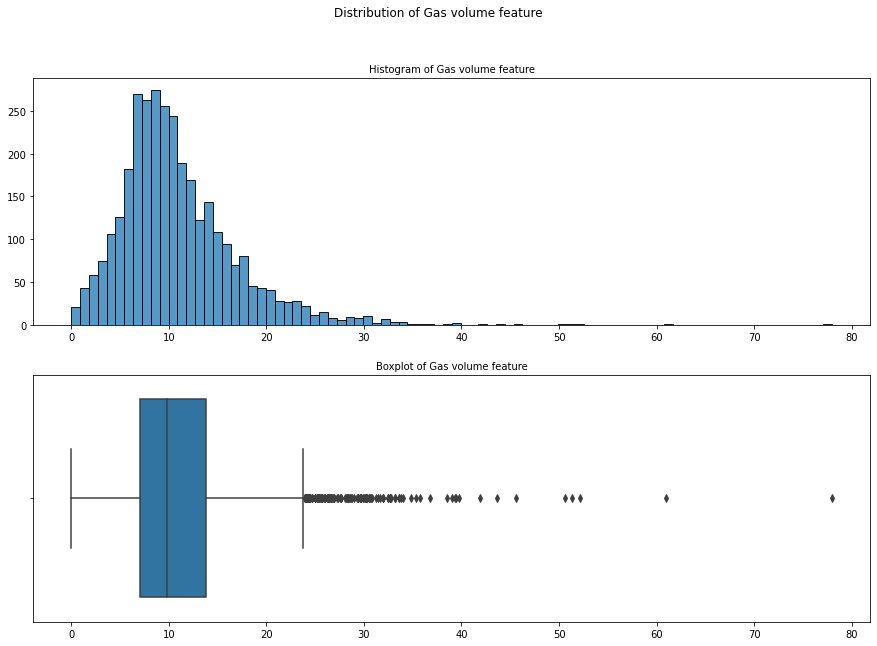

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Gas Volume Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(gas['Газ 1'], kde=False)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Gas Volume Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(gas['Газ 1'], orient='h')
plt.xlabel('')
plt.title('Boxplot of Gas Volume Feature', fontsize=10)

plt.show()

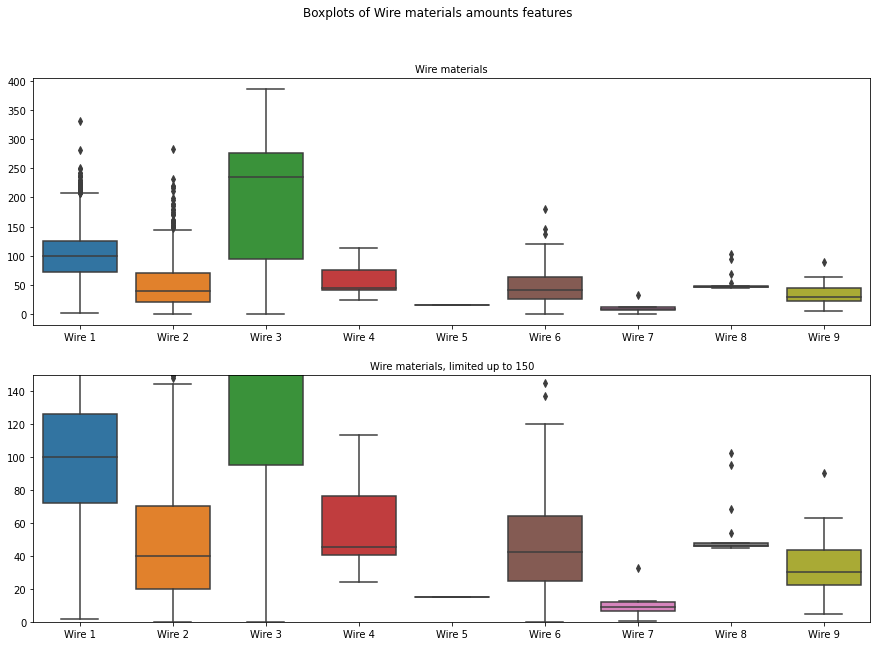

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Wire Materials Volume Features')

ax = plt.subplot(2, 1, 1)
plt.title('Wire Materials', fontsize=10)
sns.boxplot(data=wire.loc[:, 'Wire 1':'Wire 9'])

ax = plt.subplot(2, 1, 2)
plt.title('Wire Materials, limited to 150', fontsize=10)
sns.boxplot(data=wire.loc[:, 'Wire 1':'Wire 9'])
plt.ylim(0, 150)

plt.show()

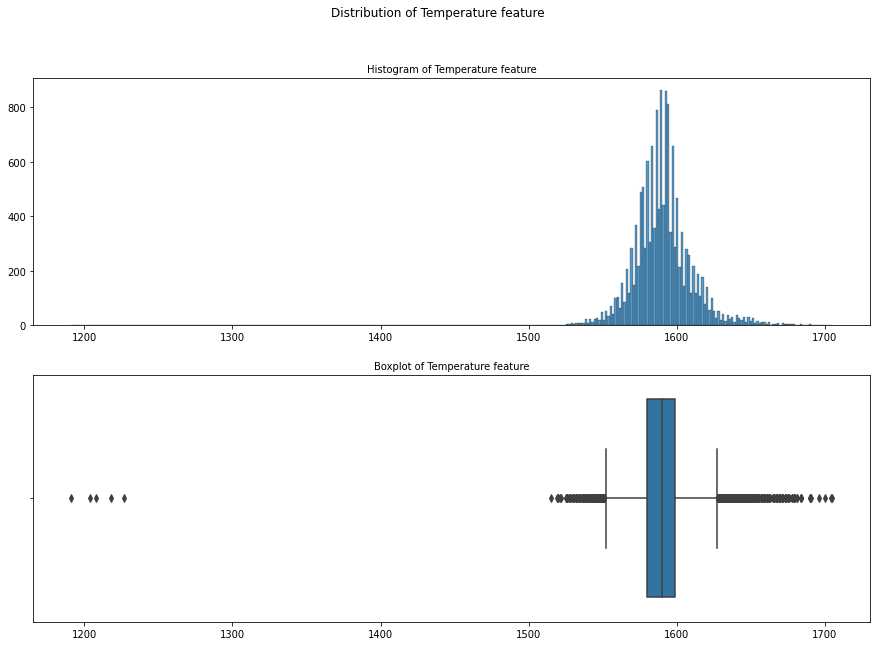

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Temperature Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(temp['Температура'], kde=False)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Temperature Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(temp['Температура'], orient='h')
plt.xlabel('')
plt.title('Boxplot of Temperature Feature', fontsize=10)

plt.show()

<h4>1.3.3. Conclusion</h4>


The data is contained in 7 datasets:<br>

- arc dataset - data on power used for alloy heating;<br>
  The dataset contains 14876 records for 3214 unique batch numbers (key), each key may correspond to multiple records.<br>
  No duplicate records, incorrect data type for heating start and end (object instead of datetime).<br>
  Active Power values range from 0.22 to 1.46, median value is 0.6, distribution has a heavy right tail.<br>
  Reactive Power values have an outlier of -715.5, excluding the outlier, values range from 0.15 to 1.27, median value is 0.4, distribution has a heavy right tail.<br>

- bulk dataset - data on bulk materials volumes added to the alloy;<br>
  The dataset contains 3129 records for 3129 unique batch numbers (key), each key corresponds to one record, and 15 types of materials.<br>
  No duplicate records, data types are correct, there are missing NaN values (most likely, material was not added).<br>
  Bulk materials volume values are heterogeneous across materials: minimum values from 1 (Bulk 15) to 228 (Bulk 2), maximum values from 49 (Bulk 8) to 1849 (Bulk 12, possibly an outlier). Bulk materials addition frequency is also heterogeneous: Bulk 8 was added to 1 batch, while Bulk 15 was added to 2806 batches.<br>

- bulk_time dataset - data on bulk materials addition time;<br>
  The dataset contains 3129 records for 3129 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are incorrect (object instead of datetime), there are missing NaN values (material was not added).<br>

- gas dataset - data on gas volume added to the alloy;<br>
  The dataset contains 3239 records for 3239 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are correct, there are missing NaN values (material was not added).<br>
  Gas volume values range from 0.008 to 78 (possibly an outlier), median value is 9.8.<br>
  
- wire dataset - data on wire materials volumes added to the alloy;<br>
  The dataset contains 3081 records for 3081 unique batch numbers (key), each key corresponds to one record, and 9 types of materials.<br>
  No duplicate records, data types are correct, there are missing NaN values (most likely, material was not added).<br>
  Wire materials volume values are heterogeneous across materials: minimum values from 0.03 (Wire 2) to 45.1 (Wire 8), maximum values from 15.1 (Wire 5) to 385 (Wire 3). Wire materials addition frequency is also heterogeneous: Wire 5 was added to 1 batch, while Wire 1 was added to 3055 batches.<br>

- wire_time dataset - data on wire materials addition time;<br>
  The dataset contains 3081 records for 3081 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are incorrect (object instead of datetime), there are missing NaN values (material was not added).<br>

- temp dataset - data on alloy temperature measurements.<br>
  The dataset contains 18092 records for 3216 unique batch numbers (key), each key may correspond to multiple records.<br>
  Each batch has initial temperature data, subsequent measurements may or may not be present. There are records with only the first temperature measurement.<br>
  No duplicate records, incorrect data type for measurement time (object instead of datetime).<br>
  Temperature values range from 1191 to 1705, median value is 1590, there are outliers in the data (alloy temperature cannot be below 1500).<br>

Next steps for data preprocessing:<br>
- Rename features (English language, lowercase);<br>
- Change data types (heating start and end features in arc dataset, temperature measurement time);<br>
- Exclude irrelevant material addition time data from further analysis;<br>
- Handle outliers (reactive power value of -715.5 in arc dataset, first and last temperature measurements below 1500 in temp dataset);<br> 
- Identify atypical values for bulk, wire materials volumes and gas;<br>
- Generate additional features;<br>
- Create a summary table where each record corresponds to one unique batch number key, with two temperature measurements (initial and final).<br>

<h3>1.4. Data Preprocessing</h3> 

<h4>1.4.1. Rename Features</h4> 

In [13]:
arc.columns = ['key', 'start_time','end_time', 
               'active_power', 'reactive_power']
gas.columns = ['key', 'gas']
temp.columns = ['key', 'time', 'temperature']
bulk.columns = ['key', 'bulk_1', 
                'bulk_2', 'bulk_3', 
                'bulk_4', 'bulk_5', 
                'bulk_6', 'bulk_7', 
                'bulk_8', 'bulk_9', 
                'bulk_10', 'bulk_11', 
                'bulk_12', 'bulk_13', 
                'bulk_14', 'bulk_15']
wire.columns = ['key', 'wire_1', 
                'wire_2', 'wire_3', 
                'wire_4', 'wire_5', 
                'wire_6', 'wire_7', 
                'wire_8', 'wire_9']

<h4>1.4.2. Change Data Types</h4> 

In [14]:
arc['start_time'] = pd.to_datetime(arc['start_time'])
arc['end_time'] = pd.to_datetime(arc['end_time'])
temp['time'] = pd.to_datetime(temp['time'])

<h4>1.4.3. Handle Data Outliers</h4> 

In [ ]:
# Remove reactive_power outlier
arc = arc[arc['reactive_power']>=0]

In [ ]:
# Remove temperature outliers

# Create pivot table with temperature measurement count, first and last measurements for each key
temp_pt = temp.pivot_table(index='key', 
                           values=['time', 'temperature'], 
                           aggfunc={'time': ['first', 'last'], 
                                    'temperature': ['first', 'last', 'count']}
                          )
# Rename pivot table columns
temp_pt.columns = [f'{agg}_{col}' for col, agg in temp_pt.columns]
# Remove outliers: temperatures less than 1500, keys with temperature measurement count less than 1
temp_pt = temp_pt[(temp_pt['count_temperature']>1) 
                  & (temp_pt['first_temperature']>=1500) 
                  & (temp_pt['last_temperature']>1500)]

# Check
display(temp_pt.head())
display(temp_pt.info())
display(temp_pt.describe())

,count_temperature,first_temperature,last_temperature,first_time,last_time
key,,,,,
1,6,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
2,5,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
3,6,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
4,5,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
5,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2471 entries, 1 to 2499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   count_temperature  2471 non-null   int64         
 1   first_temperature  2471 non-null   float64       
 2   last_temperature   2471 non-null   float64       
 3   first_time         2471 non-null   datetime64[ns]
 4   last_time          2471 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 115.8 KB


None

,count_temperature,first_temperature,last_temperature
count,2471.000000,2471.000000,2471.000000
mean,5.626467,1589.012950,1595.339943
std,1.609465,25.004369,16.035215
min,2.000000,1519.000000,1541.000000
25%,5.000000,1572.000000,1587.000000
50%,5.000000,1588.000000,1593.000000
75%,7.000000,1605.000000,1599.000000
max,17.000000,1679.000000,1700.000000


<h4>1.4.4. Generate New Features</h4> 

In [ ]:
# Create new features based on temp dataset

# Calculate production phase duration in seconds for each key
temp_pt['duration_phase'] = (temp_pt['last_time'] - temp_pt['first_time']).dt.total_seconds()

# Drop first_time and last_time features
temp_pt = temp_pt.drop(['first_time', 'last_time'], axis=1)

# Check
temp_pt.head()

,count_temperature,first_temperature,last_temperature,duration_phase
key,,,,
1,6,1571.0,1613.0,1714.0
2,5,1581.0,1602.0,1265.0
3,6,1596.0,1599.0,1753.0
4,5,1601.0,1625.0,1220.0
5,5,1576.0,1602.0,1536.0


In [ ]:
# Create new features based on arc dataset

# Calculate duration of each heating in seconds
arc['heat_duration'] = (arc['end_time'] - arc['start_time']).dt.total_seconds()

# Create pivot table with measurement count, first and last measurements for each key
arc_pt = arc.pivot_table(index='key', 
                           values=['active_power', 'reactive_power', 'heat_duration'], 
                           aggfunc={'active_power': ['count', 'mean'], 
                                    'reactive_power': ['mean'],
                                    'heat_duration': ['mean', 'sum']}
                          )
# Rename pivot table columns
arc_pt.columns = [f'{agg}_{col}' for col, agg in arc_pt.columns]

# Calculate apparent power for each key
arc_pt['apparent_power'] = np.sqrt(arc_pt['mean_active_power']**2 + arc_pt['mean_reactive_power']**2)

# Calculate power factor for each key
arc_pt['power_factor'] = arc_pt['mean_active_power'] / arc_pt['apparent_power']

# Calculate work for each key
arc_pt['work'] = arc_pt['mean_active_power'] * arc_pt['sum_heat_duration']

# Check
display(arc_pt.head())
display(arc_pt.info())
display(arc_pt.describe())

,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,power_factor,work
key,,,,,,,,
1,5,0.607346,219.60,1098.0,0.428564,0.743328,0.817063,666.865908
2,4,0.534852,202.75,811.0,0.363339,0.646593,0.827185,433.764972
3,5,0.812728,131.00,655.0,0.587491,1.002833,0.810433,532.336971
4,4,0.676622,185.25,741.0,0.514248,0.849864,0.796154,501.377087
5,4,0.563238,217.25,869.0,0.421998,0.703789,0.800293,489.453388


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3214 entries, 1 to 3241
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   count_active_power   3214 non-null   int64  
 1   mean_active_power    3214 non-null   float64
 2   mean_heat_duration   3214 non-null   float64
 3   sum_heat_duration    3214 non-null   float64
 4   mean_reactive_power  3214 non-null   float64
 5   apparent_power       3214 non-null   float64
 6   power_factor         3214 non-null   float64
 7   work                 3214 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 226.0 KB


None

,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,power_factor,work
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,4.628189,0.661327,172.339212,794.545115,0.485972,0.820930,0.805813,527.013185
std,1.608866,0.128372,45.606776,332.491076,0.097586,0.159995,0.014563,244.571363
min,1.000000,0.267676,57.000000,57.000000,0.196228,0.331897,0.739778,26.187544
25%,4.000000,0.573035,140.000000,571.000000,0.417415,0.710370,0.796620,361.696484
50%,4.000000,0.652732,168.750000,770.000000,0.481639,0.812019,0.806655,499.313525
75%,6.000000,0.739388,200.383333,983.000000,0.543312,0.916261,0.815816,668.321506
max,16.000000,1.243889,380.000000,4189.000000,0.960763,1.571727,0.857042,3456.102614


<h4>1.4.5. Create Final Dataset for Further Analysis</h4> 

In [ ]:
# Merge datasets by key
df = temp_pt.merge(arc_pt, on='key', how='inner')\
                .merge(bulk, on='key', how='inner')\
                    .merge(wire, on='key', how='inner')\
                        .merge(gas, on='key', how='inner')\
                            .set_index('key', drop=True)

# Check
display(df.head())
display(df.info())
display(df.describe())

,count_temperature,first_temperature,last_temperature,duration_phase,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
1,6,1571.0,1613.0,1714.0,5,0.607346,219.60,1098.0,0.428564,0.743328,...,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.749986
2,5,1581.0,1602.0,1265.0,4,0.534852,202.75,811.0,0.363339,0.646593,...,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.555561
3,6,1596.0,1599.0,1753.0,5,0.812728,131.00,655.0,0.587491,1.002833,...,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.554793
4,5,1601.0,1625.0,1220.0,4,0.676622,185.25,741.0,0.514248,0.849864,...,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.841219
5,5,1576.0,1602.0,1536.0,4,0.563238,217.25,869.0,0.421998,0.703789,...,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.413692


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2325 entries, 1 to 2499
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   count_temperature    2325 non-null   int64  
 1   first_temperature    2325 non-null   float64
 2   last_temperature     2325 non-null   float64
 3   duration_phase       2325 non-null   float64
 4   count_active_power   2325 non-null   int64  
 5   mean_active_power    2325 non-null   float64
 6   mean_heat_duration   2325 non-null   float64
 7   sum_heat_duration    2325 non-null   float64
 8   mean_reactive_power  2325 non-null   float64
 9   apparent_power       2325 non-null   float64
 10  power_factor         2325 non-null   float64
 11  work                 2325 non-null   float64
 12  bulk_1               199 non-null    float64
 13  bulk_2               13 non-null     float64
 14  bulk_3               958 non-null    float64
 15  bulk_4               811 non-null    f

None

,count_temperature,first_temperature,last_temperature,duration_phase,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,gas
count,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,...,2302.000000,809.000000,39.000000,12.000000,0.0,45.000000,4.000000,13.000000,24.000000,2325.000000
mean,5.696344,1587.365161,1593.366022,2323.419785,4.695914,0.664200,172.090546,807.988387,0.488928,0.824996,...,103.435430,50.597164,193.182538,59.496235,NaN,50.659374,3.703414,55.772561,30.773167,11.378942
std,1.605930,23.623144,11.209581,1385.569302,1.606250,0.128392,43.751270,340.888430,0.098004,0.160257,...,42.525047,39.800935,100.867783,30.804638,NaN,37.743040,3.818433,20.235591,15.210141,6.395632
min,2.000000,1519.000000,1541.000000,339.000000,1.000000,0.267676,57.000000,57.000000,0.196228,0.331897,...,1.918800,0.030160,0.144144,24.148801,NaN,0.137280,0.234208,45.076721,4.622800,0.008399
25%,5.000000,1571.000000,1587.000000,1581.000000,4.000000,0.576249,141.000000,581.000000,0.420051,0.713724,...,75.042236,20.180161,93.189102,38.347402,NaN,25.053600,0.849004,46.002319,20.802601,7.282948
50%,6.000000,1587.000000,1593.000000,2046.000000,5.000000,0.655642,169.500000,778.000000,0.484690,0.817669,...,102.030235,40.112801,236.972740,49.661561,NaN,40.085762,3.044704,46.187439,30.066399,10.100950
75%,7.000000,1603.000000,1598.000000,2793.000000,6.000000,0.741868,198.750000,993.000000,0.546687,0.920695,...,128.178188,70.061684,277.068801,84.755579,NaN,65.036400,5.899114,46.279999,40.495001,14.217691
max,17.000000,1660.000000,1653.000000,23674.000000,16.000000,1.243889,378.000000,4189.000000,0.960763,1.571727,...,330.314424,282.780152,385.008668,113.231044,NaN,180.454575,8.490040,102.762401,62.025600,77.995040


<h4>1.4.6. Correlation Analysis</h4> 

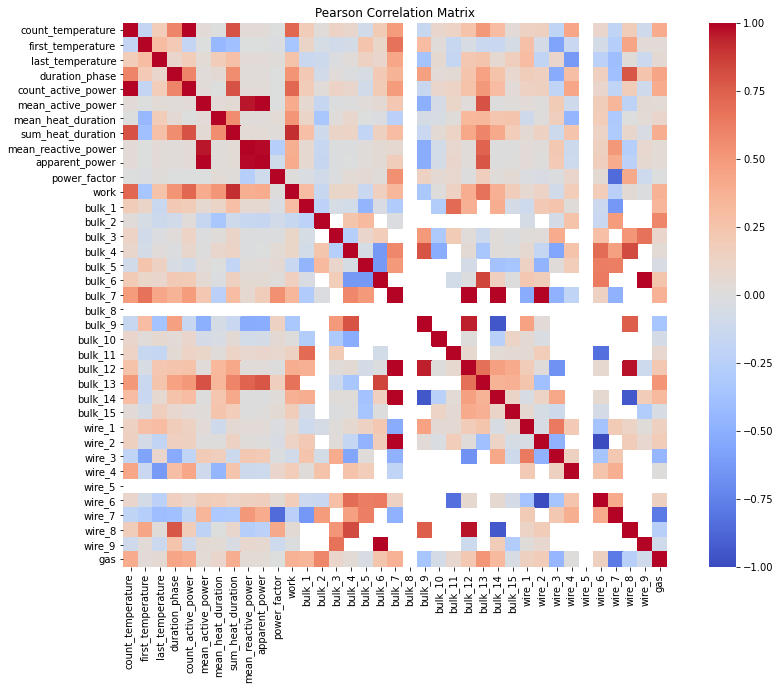

In [ ]:
# Create correlation matrix

corr = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

In [21]:
df = df.fillna(0)

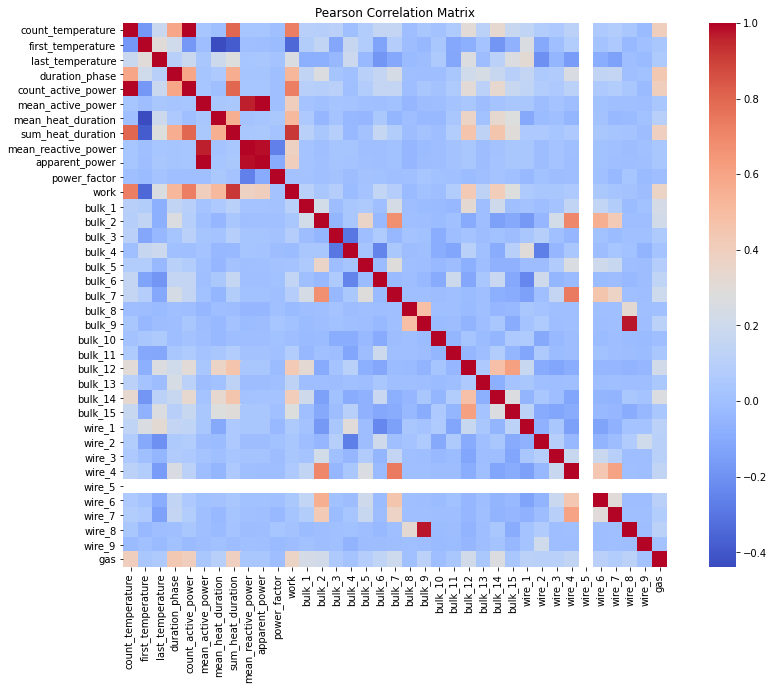

In [ ]:
corr = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

Conclusion: <br>
In the final dataset: 
- features calculated based on power logically correlate with each other (upper left corner);
- some material volume features ('bulk_2', 'bulk_7', 'bulk_9', 'bulk_13', 'wire_4', 'wire_5', 'wire_8') contain insufficient observations for correlation calculation, additionally there are cases of strong positive and strong negative correlation between materials (lower right corner);
- after preprocessing, feature 'bulk_8' contains very few observations (1), feature 'wire_5' contains no observations.

For further analysis it is necessary to: <br>
- exclude features 'bulk_8' and 'wire_5';
- exclude highly correlated features calculated based on power;
- to avoid multicollinearity problems in the model, use a linear model with regularization (Ridge Regression) or non-linear models.

In [ ]:
# Drop empty features
df = df.drop(['bulk_8', 'wire_5'], 
              axis=1
            )

# Drop correlated features
df = df.drop(['mean_active_power', 'mean_reactive_power', 
              'count_active_power', 'mean_heat_duration'], 
              axis=1
            )

# Replace NaN with 0


# Check
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2325 entries, 1 to 2499
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count_temperature  2325 non-null   int64  
 1   first_temperature  2325 non-null   float64
 2   last_temperature   2325 non-null   float64
 3   duration_phase     2325 non-null   float64
 4   sum_heat_duration  2325 non-null   float64
 5   apparent_power     2325 non-null   float64
 6   power_factor       2325 non-null   float64
 7   work               2325 non-null   float64
 8   bulk_1             2325 non-null   float64
 9   bulk_2             2325 non-null   float64
 10  bulk_3             2325 non-null   float64
 11  bulk_4             2325 non-null   float64
 12  bulk_5             2325 non-null   float64
 13  bulk_6             2325 non-null   float64
 14  bulk_7             2325 non-null   float64
 15  bulk_9             2325 non-null   float64
 16  bulk_10            2325 

None

,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
1,6,1571.0,1613.0,1714.0,1098.0,0.743328,0.817063,666.865908,0.0,0.0,...,154.0,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,29.749986
2,5,1581.0,1602.0,1265.0,811.0,0.646593,0.827185,433.764972,0.0,0.0,...,154.0,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,12.555561
3,6,1596.0,1599.0,1753.0,655.0,1.002833,0.810433,532.336971,0.0,0.0,...,153.0,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,28.554793
4,5,1601.0,1625.0,1220.0,741.0,0.849864,0.796154,501.377087,0.0,0.0,...,154.0,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,18.841219
5,5,1576.0,1602.0,1536.0,869.0,0.703789,0.800293,489.453388,0.0,0.0,...,152.0,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,5.413692


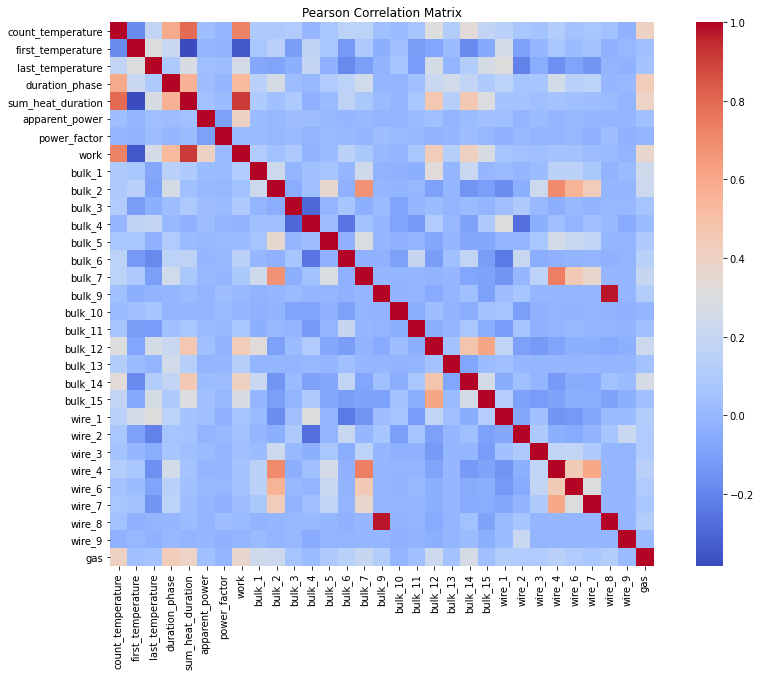

In [ ]:
corr_new = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr_new, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

<h4>1.4.7. Identify Atypical Values</h4> 

In [ ]:
# Check outliers in the entire dataset

data = df.copy().reset_index()

# Find outliers using KNN model
knn = KNN()
estimation_knn = knn.fit_predict(data)
num_outliers_knn = np.int64(len(estimation_knn[estimation_knn == 1]))
print(f'Number of outliers (KNN): {num_outliers_knn}')

# Find outliers using Isolation Forest model
iforest = IsolationForest(n_estimators=100, random_state=31123)
estimation_iforest = iforest.fit_predict(data)
num_outliers_iforest = np.int64(len(data) - len(estimation_iforest[estimation_iforest == -1]))
print(f'Number of outliers (Isolation Forest): {num_outliers_iforest}')

# Create dataframe with outliers found by both models
knn_outliers_indices = np.where(estimation_knn == 1)[0]
iforest_outliers_indices = np.where(estimation_iforest == -1)[0]
outliers_indices = np.intersect1d(knn_outliers_indices, iforest_outliers_indices)
print(f'Number of outliers (both models): {len(outliers_indices)}')

Number of outliers (KNN): 233
Number of outliers (Isolation Forest): 2287
Number of outliers (both models): 36


In [ ]:
# Outliers
outliers = data[data.index.isin(outliers_indices)].set_index('key', drop=True)

display(outliers.head())
display(outliers.describe())

display(outliers[outliers['bulk_12']>1700])
display(outliers[outliers['gas']>70])

,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
44,13,1600.0,1603.0,10976.0,2063.0,0.747851,0.813330,1254.819062,0.0,0.0,...,159.0,69.189123,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,21.265271
45,11,1538.0,1621.0,4887.0,2136.0,0.775724,0.808571,1339.759222,0.0,0.0,...,204.0,114.354237,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,18.601690
46,14,1607.0,1612.0,12323.0,2919.0,0.890473,0.793033,2061.321232,0.0,0.0,...,204.0,100.245593,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,6.118441
113,5,1645.0,1647.0,4550.0,819.0,0.982532,0.831254,668.904941,0.0,228.0,...,0.0,7.556640,0.0,96.047951,24.148801,60.094322,0.0,0.0,0.0,25.377930
114,4,1631.0,1600.0,4731.0,519.0,0.560224,0.779058,226.515993,0.0,247.0,...,0.0,0.000000,0.0,88.648567,43.065361,54.122643,0.0,0.0,0.0,14.683228


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,9.055556,1607.500000,1593.138889,8196.972222,1506.000000,0.833900,0.806953,1038.103641,24.777778,92.027778,...,85.916667,94.009412,36.239522,31.167137,16.271869,23.975382,0.411490,1.277842,2.637989,27.256830
std,3.748862,33.443769,26.568674,5449.470766,884.456896,0.146212,0.013343,668.386831,38.820548,125.072890,...,103.650891,83.362002,69.084775,44.664305,30.301398,34.250894,1.625746,7.667053,11.176375,15.371763
min,2.000000,1520.000000,1541.000000,2690.000000,161.000000,0.484789,0.777527,78.265642,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.120463
25%,7.000000,1589.500000,1579.750000,3937.250000,817.750000,0.743825,0.801375,568.007377,0.000000,0.000000,...,0.000000,4.051320,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.242287
50%,9.000000,1618.000000,1600.000000,7001.500000,1409.500000,0.858422,0.809487,1040.788436,0.000000,0.000000,...,0.000000,99.153596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.147420
75%,11.250000,1629.500000,1612.500000,11155.000000,1959.500000,0.955350,0.816006,1276.054102,40.000000,242.000000,...,203.000000,162.629998,52.636738,93.080990,26.407162,60.042844,0.000000,0.000000,0.000000,32.736485
max,17.000000,1652.000000,1647.000000,23674.000000,4189.000000,1.041395,0.831254,3456.102614,185.000000,325.000000,...,337.000000,236.667587,282.780152,97.008911,113.231044,99.219122,8.490040,46.002319,55.000397,77.995040


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
322,14,1619.0,1616.0,7011.0,2658.0,0.851597,0.805257,1822.73495,185.0,0.0,...,0.0,0.0,188.22855,0.0,0.0,0.0,0.0,0.0,0.0,77.99504


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
322,14,1619.0,1616.0,7011.0,2658.0,0.851597,0.805257,1822.73495,185.0,0.0,...,0.0,0.0,188.22855,0.0,0.0,0.0,0.0,0.0,0.0,77.99504


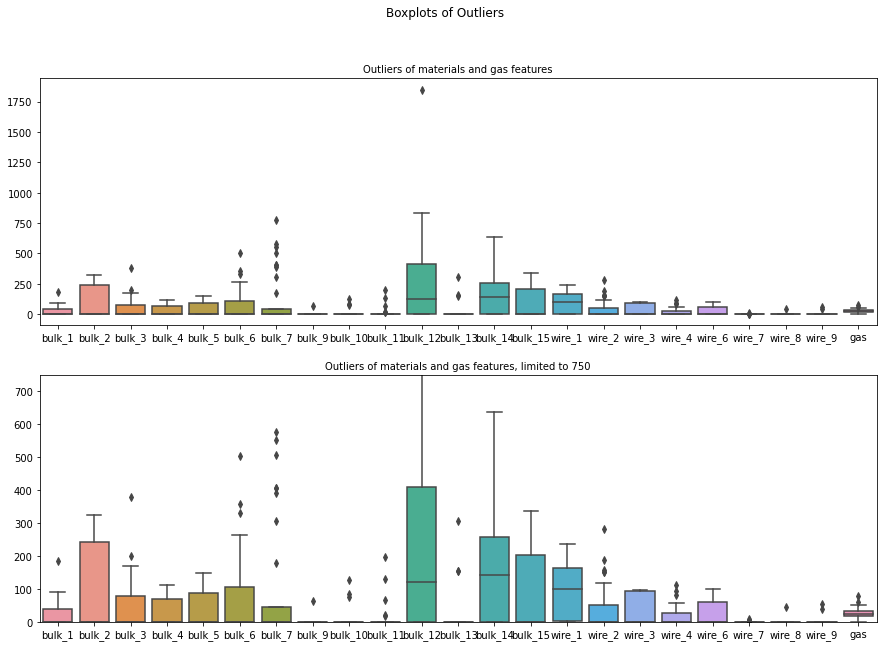

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Outliers')

ax = plt.subplot(2, 1, 1)
plt.title('Outliers of Materials and Gas Features', fontsize=10)
sns.boxplot(data=outliers.loc[:, 'bulk_1':'gas'])

ax = plt.subplot(2, 1, 2)
plt.title('Outliers of Materials and Gas Features, limited to 750', fontsize=10)
sns.boxplot(data=outliers.loc[:, 'bulk_1':'gas'])
plt.ylim(0, 750)

plt.show()

Conclusion: <br>
KNN and Isolation Forest models jointly found 36 records containing atypical values. The list of such values includes a batch with atypically high bulk_12 volume of 1849 and gas volume of 77.99 (these values were found during exploratory data analysis).
For further analysis, to improve model quality, the identified atypical records can be excluded from the training set. 

<h4>1.4.8. Conclusion</h4> 

The final dataset created for further analysis contains 2325 records for 2325 batch numbers, each batch corresponds to one record.<br>
The final dataset includes features:
- count_temperature - number of temperature measurement iterations for the alloy batch;
- first_temperature - first temperature measurement value for the alloy batch;
- last_temperature - last temperature measurement value for the alloy batch (target feature);
- duration_phase - duration of this production phase for the alloy batch (in seconds);
- sum_heat_duration - total heating duration for the alloy batch (in seconds);
- apparent_power - apparent power for the alloy batch (square root of sum of squares of mean active power and mean reactive power);
- power_factor - average power factor for the alloy batch heating;
- work - work done for heating the alloy batch (product of mean active power and total heating duration in seconds);
- bulk_i - volumes of bulk material i additions to the alloy batch;
- wire_j - volumes of wire material j additions to the alloy batch;
- gas - gas volumes for the alloy batch.

<h2> Part 2. Model Definition </h2> 

<h3>2.1. Preparation</h3> 

<h4>2.1.1. Fix Parameters</h4> 

In [28]:
RANDOM_STATE = 31123

<h4>2.1.2. Define Features</h4> 

In [29]:
y = df['last_temperature']
x = df.drop('last_temperature', axis=1)

<h4>2.1.3. Split Data into Training and Test Sets</h4> 

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y, 
                                                    test_size=0.25, 
                                                    random_state=RANDOM_STATE
                                                    )

print(f'Training set size: {x_train.shape, y_train.shape}')
print(f'Test set size: {x_test.shape, y_test.shape}')

Size of train data: ((1743, 30), (1743,))
Size of test data: ((582, 30), (582,))


In [ ]:
x_train = x_train[~x_train.index.isin(outliers.index)]
y_train = y_train[~y_train.index.isin(outliers.index)]

print(f'Training set size: {x_train.shape, y_train.shape}')
print(f'Test set size: {x_test.shape, y_test.shape}')

Size of train data: ((1717, 30), (1717,))
Size of test data: ((582, 30), (582,))


<h3>2.2. Model Training</h3> 

<h4>2.2.1. Linear Model (Ridge Regression)</h4> 

In [32]:
interval_cols = [col for col, dtype in x.dtypes.items() if (dtype == 'int64' or dtype == 'float64')]

In [ ]:
# Define objective function for Optuna
def objective_lr(trial, error_score='raise'):

    params_lr = {'alpha': trial.suggest_uniform('alpha', 0.0, 1.0),
                 'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'lsqr'])
                }
    model_lr = Ridge(**params_lr, random_state=RANDOM_STATE)

    pipe_lr = Pipeline(
                    [
                    ('transformation', ColumnTransformer(
                                            transformers=[
                                                ('scaler', StandardScaler(), interval_cols)
                                                ],
                                                remainder='passthrough',
                                                n_jobs=-1
                                                )
                    ), 
                    ('model', model_lr)
                    ]
                    )
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(pipe_lr, 
                             x_train, 
                             y_train, 
                             cv=kfold, 
                             scoring='neg_mean_absolute_error'
                             )
    mae_lr = -scores.mean()

    return mae_lr

In [ ]:
%%time

# Create Optuna study
study_lr = optuna.create_study(direction='minimize')

# Optimize hyperparameters
study_lr.optimize(objective_lr, n_trials=100)

[I 2023-11-09 13:50:28,329] A new study created in memory with name: no-name-b913ac8d-181a-4ae0-9703-ea613cda5052
[I 2023-11-09 13:50:29,119] Trial 0 finished with value: 5.666637023543566 and parameters: {'alpha': 0.7077895139534582, 'solver': 'lsqr'}. Best is trial 0 with value: 5.666637023543566.
[I 2023-11-09 13:50:30,418] Trial 1 finished with value: 5.667836514631764 and parameters: {'alpha': 0.7129244204303442, 'solver': 'svd'}. Best is trial 0 with value: 5.666637023543566.
[I 2023-11-09 13:50:31,215] Trial 2 finished with value: 5.667899839110249 and parameters: {'alpha': 0.5627446759681894, 'solver': 'auto'}. Best is trial 0 with value: 5.666637023543566.
[I 2023-11-09 13:50:32,016] Trial 3 finished with value: 5.672307023108521 and parameters: {'alpha': 0.2820413463290792, 'solver': 'auto'}. Best is trial 0 with value: 5.666637023543566.
[I 2023-11-09 13:50:33,008] Trial 4 finished with value: 5.667992145642887 and parameters: {'alpha': 0.4959111519016072, 'solver': 'auto'}.

CPU times: user 48 s, sys: 57 s, total: 1min 45s
Wall time: 1min 45s


In [ ]:
# Return cross-validation MAE of Ridge Regression model
best_trial_lr = study_lr.best_trial
train_mae_lr = best_trial_lr.value

print(f'MAE of Ridge Regression on training set: {train_mae_lr:.5}')

MAE of Ridge Regression on train dataset: 5.6665


In [ ]:
# Train Ridge Regression model with best hyperparameters
best_params_lr = study_lr.best_params
best_model_lr = Ridge(**best_params_lr)
best_model_lr.fit(x_train, y_train)

Ridge(alpha=1.6377897250108233e-05, solver='lsqr')

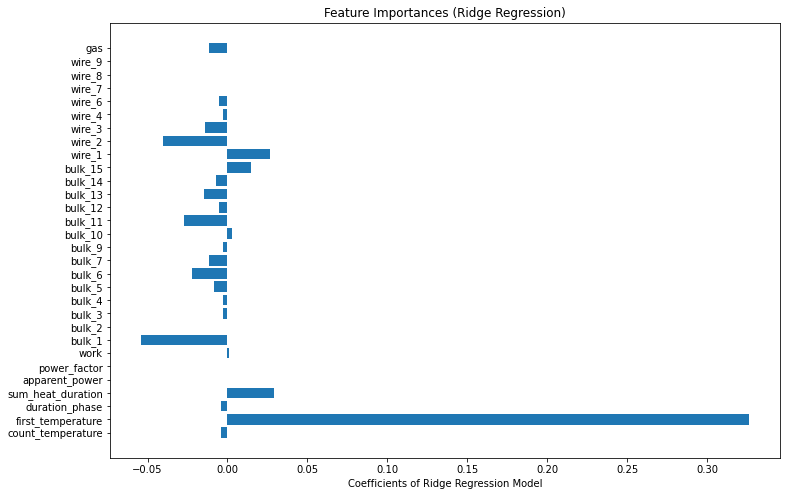

In [ ]:
# Plot Ridge Regression coefficients
coef_lr = best_model_lr.coef_
feature_names = x_train.columns

plt.figure(figsize=(12, 8))
plt.barh(range(len(coef_lr)), coef_lr, tick_label=feature_names)
plt.xlabel('Ridge Regression Model Coefficients')
plt.title('Feature Importances (Ridge Regression)')
plt.show()

<h4>2.2.2. Gradient Boosting Model (CatBoost Regressor)</h4> 

In [ ]:
# Define objective function for Optuna
def objective_cb(trial):
    
    # Define hyperparameters to optimize
    params_cb = {'iterations': trial.suggest_int('iterations', 100, 1000),
                 'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
                'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.01, 100),
#                'per_float_feature_quantization': trial.suggest_categorical('per_float_feature_quantization', [None, '1:border_count=1024', ]),
                 'depth': trial.suggest_int('depth', 4, 10),
#                'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),
                 'loss_function': 'MAE',
                }

    model_cb = CatBoostRegressor(**params_cb, verbose=0, random_state=RANDOM_STATE)

    pipe_cb = Pipeline(
                    [
                    ('transformation', ColumnTransformer(
                                            transformers=[
                                                ('scaler', StandardScaler(), interval_cols)
                                                ],
                                                remainder='passthrough',
                                                n_jobs=-1
                                                )
                    ), 
                    ('model', model_cb)
                    ]
                    )

    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe_cb, 
                             x_train, 
                             y_train, 
                             cv=kfold, 
                             scoring='neg_mean_absolute_error'
                             )
    mae_cb = -scores.mean()

    return mae_cb

In [ ]:
%%time

# Create Optuna study
study_cb = optuna.create_study(direction='minimize')

# Optimize hyperparameters
study_cb.optimize(objective_cb, n_trials=200)

[I 2023-11-09 13:52:14,537] A new study created in memory with name: no-name-2649236d-5a0f-46aa-bf5c-b6abb33b9dbb
[I 2023-11-09 13:53:01,001] Trial 0 finished with value: 5.770107653084877 and parameters: {'iterations': 724, 'learning_rate': 0.033969037611994234, 'l2_leaf_reg': 4.346787947542521, 'depth': 8}. Best is trial 0 with value: 5.770107653084877.
[I 2023-11-09 13:53:13,903] Trial 1 finished with value: 5.8953373262700435 and parameters: {'iterations': 476, 'learning_rate': 0.1586726179192746, 'l2_leaf_reg': 0.015678091071581905, 'depth': 6}. Best is trial 0 with value: 5.770107653084877.
[I 2023-11-09 13:53:42,484] Trial 2 finished with value: 5.782633582456562 and parameters: {'iterations': 414, 'learning_rate': 0.02596793338552924, 'l2_leaf_reg': 47.20012859713598, 'depth': 8}. Best is trial 0 with value: 5.770107653084877.
[I 2023-11-09 13:55:13,234] Trial 3 finished with value: 6.107084106832255 and parameters: {'iterations': 761, 'learning_rate': 0.1496328334560879, 'l2_l

In [ ]:
# Return cross-validation MAE of CatBoost Regressor model
best_trial_cb = study_cb.best_trial
train_mae_cb = best_trial_cb.value

print(f'MAE of CatBoost Regressor on training set: {train_mae_cb:.5}')

In [ ]:
# Train CatBoost model with best hyperparameters
best_params_cb = study_cb.best_params
best_model_cb = CatBoostRegressor(**best_params_cb, verbose=0)
best_model_cb.fit(x_train, y_train)

In [ ]:
# Plot feature importances of CatBoost Regressor model
feature_importances = best_model_cb.feature_importances_
feature_names = x_train.columns

sorted_indices = feature_importances.argsort()[::-1]
sorted_feature_importances = feature_importances[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_feature_importances)
plt.xlabel('Feature Importances')
plt.title('Feature Importances (CatBoost Regressor)')
plt.show()

<h4>2.2.3. Select Best Model</h4> 

In [ ]:
models_scores = {'Ridge Regression': [train_mae_lr, best_params_lr],
                'Catboost Regressor': [train_mae_cb, best_params_cb]
                }
models_scores = pd.DataFrame(models_scores, index=['Training MAE', 'Model Hyperparameters'])

display(models_scores)

In [ ]:
best_model_name = min(models_scores, key=lambda k: models_scores[k][0])
best_model_train_mae = models_scores[best_model_name][0]
best_model_params = models_scores[best_model_name][1]

print(f'Best model: {best_model_name}')
print(f'Training MAE of best model: {best_model_train_mae:.5}')
print(f'Best model hyperparameters: {best_model_params}')

Conclusion: <br>
The model with the lowest error on the training set is the CatBoost Regressor with model parameters: iterations 981, learning rate 0.044, regularization coefficient 0.67, model depth 4. <br>
The MAE of the best model is 5.61 on the training set. <br>
The Ridge Regression model has comparable results on the training set and, additionally, trains faster and therefore can also be used for analysis.

<h3>2.3. Test Best Model</h3> 

In [ ]:
# Calculate MAE of CatBoost Regressor model on test set
y_test_pred_cb = best_model_cb.predict(x_test)
test_mae_cb = mean_absolute_error(y_test, y_test_pred_cb)
print(f'MAE of CatBoost Regressor on test set: {test_mae_cb:.5}')

Conclusion: <br>
The MAE of the best CatBoost Regressor model on the test set is 6.1. <br>
The MAE on the test set is comparable to the MAE on the training set, there is no model overfitting.

<h3>2.4. Report</h3> 

Based on historical data about production stages and alloy characteristics during steel production, models for predicting the final alloy temperature were developed. <br>
According to the analysis results, the CatBoost Regressor model was selected as the best model for prediction. The error of this model is minimal among all considered models, on average the temperature prediction of this model deviates from the actual value by 6.1 degrees.
According to the model results, the greatest influence on the final steel temperature is exerted by the initial alloy temperature and the total heating time of the alloy. Additionally, the time the alloy spends at this production stage and the power factor coefficient value also significantly affect the result. Among materials, the most significant are the volume of Wire 1 wire material addition and the volume of Bulk 6 bulk material addition.